# Brace PIC on the openhdemg sample data

This notebook demonstrates the explicit `brace_pic` workflow on the bundled `openhdemg` sample decomposition:

1. Load the sample `openhdemg` data.
2. Convert one MU's discharge pulses to a smoothed discharge-rate trace.
3. Run a deterministic `compute_brace_pic(...)` calculation and plot the geometry.
4. Re-run `compute_brace_pic(...)` with 20,000 HDI draws and report the returned draw-mean point estimates.
5. Run sensitivity analyses for endpoint placement, endpoint/window averaging, phase fitting, peak-force tolerance, and local SVR smoother settings.

The openhdemg sample is useful for exercising the workflow, but it may not be an ideal triangular-ramp PIC validation trial. Always inspect `result.valid`, `result.exclusion_reasons`, and the plotted geometry before interpreting PIC metrics.

## Interpretation of PIC Metrics following Beauchamp et al. (2023)

## 1. ΔF metrics: paired MU analysis

| Metric | What it measures                                                                                                                                          | Physiological interpretation                                                                                                                                                                                                                                                                                                                              | Benefits                                                                                                                                                                                                                                                                     | Limitations                                                                                                                                                                                                                                                                                                                                                                                                                                                                      |
| ------ | --------------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **ΔF** | The change in discharge rate of a lower-threshold **reporter MU** between recruitment and derecruitment of a higher-threshold **test MU**. Unit: **pps**. | Primarily reflects **PIC prolongation / discharge hysteresis**: the test MU derecruits at a lower estimated synaptic drive than was needed for recruitment. Larger ΔF is generally interpreted as stronger persistent depolarizing current, often linked more closely to slower, persistent CaPIC-mediated hysteresis than to rapid onset amplification.  | Well-established, extensively used, and physiologically intuitive for hysteresis. It directly targets the recruitment–derecruitment mismatch that is a hallmark of PIC prolongation. In repeated matched-MU observations, ΔF showed variability comparable to brace height.  | It is a **paired-unit metric**, so it depends on both the reporter MU and the test MU. Changes cannot be isolated to the test MU alone. It requires suitable lower-threshold reporter units, common-drive criteria, adequate recruitment-time separation, and non-saturated reporter discharge; therefore, it produces fewer valid estimates and is weak for the lowest-threshold MUs. It is also influenced by inhibitory pattern, so ΔF is not a pure neuromodulation measure. |

**Practical interpretation:** ΔF is best read as a **hysteresis/prolongation metric**. A high ΔF suggests stronger persistent depolarizing support after recruitment, but changes in ΔF may reflect **neuromodulation, inhibition, reporter-unit behavior, or their interaction**.

---

## 2. Brace-method metrics: single-MU geometric analysis

The brace method uses the smoothed MU discharge-rate trace plotted against reference force/torque. The paper generated instantaneous discharge rate from MU spike trains, smoothed it with SVR, and evaluated a continuous discharge-rate estimate sampled at 2048 Hz before calculating the metrics. 

| Metric                          | What it measures                                                                                                                                                                                                    | Physiological interpretation                                                                                                                                                                                                                                        | Benefits                                                                                                                                                                                                                                                                                            | Limitations                                                                                                                                                                                                                                                                                                                                                      |
| ------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Brace height, BH**            | Maximum **orthogonal deviation** of the smoothed MU discharge-vs-force trace from the straight recruitment-to-peak-discharge line, normalized to the height of the corresponding right triangle. Unit: **% rTri**.  | Index of **PIC amplification** during the ascending ramp. A larger BH means the MU discharge rises more nonlinearly above a passive linear input–output relation, consistent with stronger intrinsic activation by PICs and neuromodulatory drive.                  | Single-MU metric; does not require a reporter MU. In simulations, BH increased consistently with neuromodulation and was comparatively less sensitive to inhibitory pattern, making it useful for separating neuromodulatory from inhibitory effects. It also yielded more valid estimates than ΔF. | Does **not** quantify recruitment–derecruitment hysteresis, so it may miss PIC prolongation that ΔF captures. It may reflect faster NaPIC-related amplification more than slower CaPIC-related hysteresis. It can fail to characterize MUs that peak early and then decline before peak torque; a third post-peak-discharge region may be needed for such units. |
| **Acceleration slope, ACC**     | Slope from recruitment to the brace point. Unit: usually **pps/%MVT**.                                                                                                                                              | Represents the early high-gain “secondary range,” where MU discharge rises steeply after recruitment. Higher ACC is interpreted as faster MU “turn-on,” plausibly reflecting intrinsic PIC-mediated amplification.                                                  | Captures early recruitment dynamics that BH alone compresses into one deviation value. Useful when the early discharge rise itself is of interest.                                                                                                                                                  | More variable than BH and ΔF in repeated observations. It is sensitive to recruitment timing, smoothing, endpoint definition, and the briefness of the acceleration phase. In simulations, its neuromodulation sensitivity was less consistent than BH.                                                                                                          |
| **Attenuation slope, ATT**      | Slope from the brace point to peak discharge. Unit: usually **pps/%MVT**.                                                                                                                                           | Represents the later “tertiary range,” where further increases in force produce attenuated increases in discharge rate. The paper interprets this region as one in which PICs are likely already strongly or fully activated and the MU approaches peak discharge.  | In simulations, ATT was the brace-derived metric most consistently associated with **inhibitory command pattern / excitation–inhibition coupling**. Combined with BH, it may help decouple neuromodulatory drive from inhibitory profile.                                                           | Not a pure PIC-amplitude metric. It depends on rate modulation, peak discharge, and how the brace point is chosen. If ACC and ATT are both high, the discharge profile may be relatively linear despite high slopes, implying less PIC-specific curvature.                                                                                                       |
| **Angle, ANG**                  | Angle between the acceleration and attenuation phases at the brace point. Unit: **degrees**.                                                                                                                        | Shape descriptor of the transition from steep early discharge increase to attenuated later discharge increase. Larger angles generally indicate a stronger bend/nonlinearity in the ascending MU discharge profile.                                                 | Compact descriptor of brace geometry. In matched-MU analysis, angle showed low variability compared with other metrics, though the authors caution that this may partly reflect its high average values.                                                                                            | Physiological specificity is weaker than BH or ATT. It can parallel BH but does not uniquely distinguish neuromodulation from other shape effects. It is also sensitive to axis scaling unless force/torque and discharge-rate units are standardized, e.g. %MVT and pps.                                                                                        |
| **Brace point timing/location** | The force/torque and discharge-rate point at which BH occurs.                                                                                                                                                       | Marks the transition from early high-gain acceleration to later attenuated discharge. Operationally separates secondary and tertiary discharge ranges.                                                                                                              | Useful diagnostic marker for plotting, QC, and segmenting the MU discharge profile.                                                                                                                                                                                                                 | Sensitive to smoothing, noise, sampling, and endpoint choices. Edge brace points or brace points near recruitment/peak are usually unstable and should be inspected.                                                                                                                                                                                             |

## Summary interpretation

**ΔF** mainly indexes **PIC prolongation / hysteresis**, but it is confounded by the reporter MU and by inhibitory pattern. **Brace height** mainly indexes **PIC amplification / neuromodulatory drive** at the single-MU level. **Attenuation slope** appears most useful as an indicator of **inhibitory command pattern**, while **acceleration slope** and **angle** provide additional shape information about early PIC-related turn-on and the transition into attenuated firing. The paper’s central conclusion is that brace height and attenuation slope can complement ΔF by helping separate neuromodulatory drive from excitation–inhibition coupling.


## Setup

Run this notebook from the repository root or from the `notebooks/` directory. The import cell adds `../src` or `src` to `sys.path` so it uses the local checkout.

In [1]:
from __future__ import annotations

import itertools
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
repo_root = cwd.parent if cwd.name == "notebooks" else cwd
src = repo_root / "src"
if src.exists() and str(src) not in sys.path:
    sys.path.insert(0, str(src))

try:
    import openhdemg.library as emg
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "This notebook uses openhdemg's bundled sample data. Install openhdemg "
        "in the active environment, then rerun this cell."
    ) from exc

from hdsemg_shared.motor_unit.discharge_rate import (
    firing_times_from_indices,
    instantaneous_discharge_rate,
    smooth_discharge_rate_svr,
)
from hdsemg_shared.motor_unit.brace_pic import (
    CIOptions,
    compute_brace_pic,
    plot_brace,
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.rcParams["figure.dpi"] = 120

## User-adjustable analysis parameters

`N_HDI_DRAWS` is set to 20,000. For quick debugging, temporarily lower it and rerun only the HDI section.

`SMOOTHER_KWARGS` contains the SVR settings used for both the deterministic trace and jitter-SVR HDI draws. Keep these close to the paper/method settings unless you are explicitly testing smoothing sensitivity.

In [2]:
MU_INDEX = 4

# Evaluation grid for the smoothed discharge-rate trace. A fixed number keeps
# the 20k-draw notebook practical while preserving the MU active time span.
N_EVAL = 2048

# SVR smoother settings used to create the input trace for compute_brace_pic.
# These override the shared smooth_discharge_rate_svr defaults and should track
# the paper/method settings being validated.
SMOOTHER_KWARGS = {
    "C": 20.0,
    "gamma": 0.5,
}

# Main brace PIC settings. Every value here is passed to compute_brace_pic.
BRACE_KWARGS = {
    "reference_unit": "%MVC",
    "discharge_unit": "pps",
    "distance_mode": "positive",
    "phase_fit": "endpoints",
    "recruitment_window": 1,
    "peak_window": 1,
    "brace_window": 1,
    "peak_torque_tolerance_s": 0.0,
}

N_HDI_DRAWS = 20_000
RANDOM_STATE = 123
N_JOBS = -1

print("SVR smoother kwargs:", SMOOTHER_KWARGS)
print("HDI draws:", N_HDI_DRAWS)

SVR smoother kwargs: {'C': 20.0, 'gamma': 0.5}
HDI draws: 20000


## Load openhdemg sample data

`emg_from_samplefile()` returns an example decomposed file with `MUPULSES`, `REF_SIGNAL`, and `FSAMP` fields.

In [3]:
emgfile = emg.emg_from_samplefile()

fsamp = float(emgfile["FSAMP"])
n_mu = int(emgfile["NUMBER_OF_MUS"])
ref_signal = emgfile["REF_SIGNAL"].iloc[:, 0].to_numpy(dtype=float)
ref_time = np.arange(ref_signal.size, dtype=float) / fsamp

print(f"Source: {emgfile.get('SOURCE', 'unknown')}")
print(f"Sampling frequency: {fsamp:g} Hz")
print(f"Recording length: {ref_signal.size} samples ({ref_signal.size / fsamp:.2f} s)")
print(f"Number of MUs: {n_mu}")

pd.DataFrame({
    "MU": np.arange(n_mu),
    "n_discharges": [len(np.asarray(p)) for p in emgfile["MUPULSES"]],
    "first_s": [np.asarray(p, dtype=float)[0] / fsamp if len(np.asarray(p)) else np.nan for p in emgfile["MUPULSES"]],
    "last_s": [np.asarray(p, dtype=float)[-1] / fsamp if len(np.asarray(p)) else np.nan for p in emgfile["MUPULSES"]],
})

Source: OTB
Sampling frequency: 2048 Hz
Recording length: 66560 samples (32.50 s)
Number of MUs: 5


,MU,n_discharges,first_s,last_s
0,0,137,2.436523,28.846191
1,1,154,4.998047,27.938477
2,2,197,3.448242,28.848145
3,3,293,2.203613,30.137695
4,4,292,2.347656,30.449219


## Build the smoothed discharge-rate trace

`compute_brace_pic(...)` expects a smoothed discharge-rate trace and a reference trace on the same time base. This helper builds those arrays from the openhdemg pulse indices.

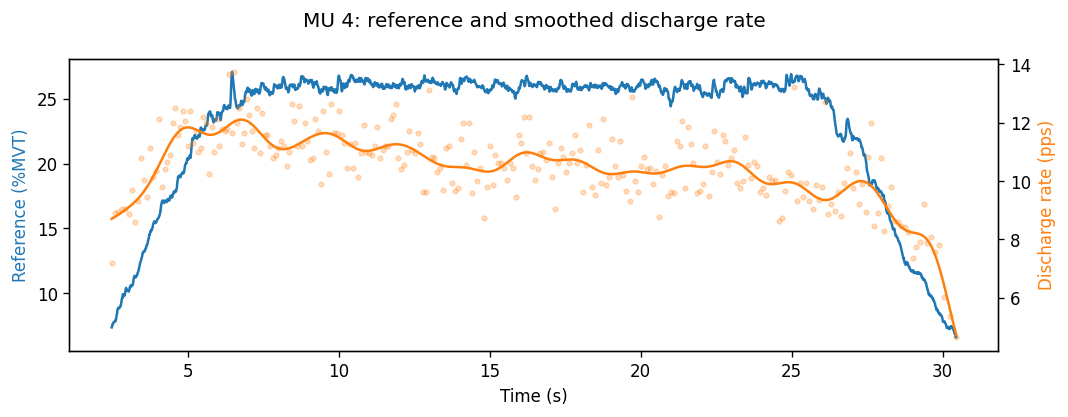

In [4]:
def make_mu_trace(emgfile, mu_index: int, *, n_eval: int, smoother_kwargs: dict):
    fsamp = float(emgfile["FSAMP"])
    ref = emgfile["REF_SIGNAL"].iloc[:, 0].to_numpy(dtype=float)
    pulses = np.asarray(emgfile["MUPULSES"][mu_index], dtype=float)
    if pulses.size < 3:
        raise ValueError(f"MU {mu_index} has too few discharges for an IDR trace.")

    firing_times = firing_times_from_indices(pulses, fsamp)
    rate_times, idr = instantaneous_discharge_rate(firing_times)

    t_eval = np.linspace(rate_times[0], rate_times[-1], int(n_eval))
    _, smooth_rate = smooth_discharge_rate_svr(rate_times, idr, t_eval, **smoother_kwargs)

    ref_time = np.arange(ref.size, dtype=float) / fsamp
    ref_on_rate = np.interp(t_eval, ref_time, ref)
    peak_reference_idx = int(np.nanargmax(ref_on_rate))

    return {
        "pulses": pulses,
        "firing_times": firing_times,
        "rate_times": rate_times,
        "idr": idr,
        "time": t_eval,
        "smooth_rate": np.asarray(smooth_rate, dtype=float),
        "reference": ref_on_rate,
        "peak_reference_idx": peak_reference_idx,
    }

trace = make_mu_trace(emgfile, MU_INDEX, n_eval=N_EVAL, smoother_kwargs=SMOOTHER_KWARGS)

fig, ax1 = plt.subplots(figsize=(9, 3.5))
ax1.plot(trace["time"], trace["reference"], color="tab:blue", label="reference")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Reference (%MVT)", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(trace["time"], trace["smooth_rate"], color="tab:orange", label="smoothed DR")
ax2.scatter(trace["rate_times"], trace["idr"], s=8, color="tab:orange", alpha=0.25, label="IDR")
ax2.set_ylabel("Discharge rate (pps)", color="tab:orange")
fig.suptitle(f"MU {MU_INDEX}: reference and smoothed discharge rate")
fig.tight_layout()
plt.show()

## Deterministic brace PIC calculation and plot

This cell passes all deterministic geometry options directly to `compute_brace_pic(...)`.

Interpret the geometry and sensitivity outputs as diagnostics, not as a reportable PIC estimate.


,brace_height_norm,brace_height,acceleration_slope,attenuation_slope,angle,valid,exclusion_reasons,recruitment_idx,brace_idx,peak_idx,peak_reference_idx
0,24.926755,0.849086,0.276051,0.073506,191.228197,False,peak discharge after peak force/torque,0,156,314,292


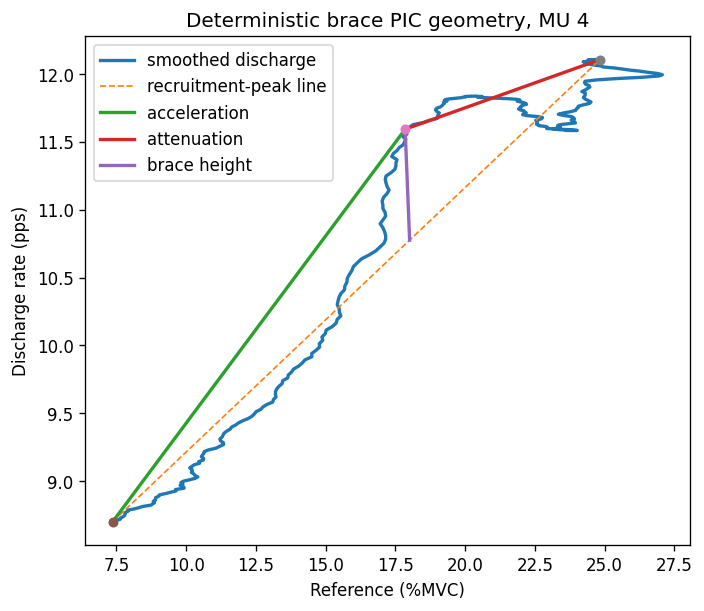

In [5]:
deterministic = compute_brace_pic(
    trace["smooth_rate"],
    trace["reference"],
    fsamp=fsamp,
    time=trace["time"],
    peak_reference_idx=trace["peak_reference_idx"],
    **BRACE_KWARGS,
)

if not deterministic.valid:
    print("WARNING: deterministic brace result is invalid:", "; ".join(deterministic.exclusion_reasons))
    print("Interpret the geometry and sensitivity outputs as diagnostics, not as a reportable PIC estimate.")

deterministic_summary = pd.DataFrame([deterministic.as_dict(include_ci=False)])
display(deterministic_summary[[
    "brace_height_norm", "brace_height", "acceleration_slope",
    "attenuation_slope", "angle", "valid", "exclusion_reasons",
    "recruitment_idx", "brace_idx", "peak_idx", "peak_reference_idx",
]])

fig, ax = plt.subplots(figsize=(6.5, 5.5))
plot_brace(deterministic, ax=ax, title=f"Deterministic brace PIC geometry, MU {MU_INDEX}")
ax.legend(loc="best")
plt.show()

## 20,000-draw HDI estimate

When `ci` is requested and finite draws are available, `compute_brace_pic(...)` returns the draw mean as each scalar point estimate. The HDI bounds and draw summaries are stored in `result.ci.intervals`.

In [6]:
hdi_options = CIOptions(
    level=95,
    method="jitter_svr",
    interval="hdi",
    n_draws=N_HDI_DRAWS,
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
    store_draws=True,
    store_trace_summary=False,
    svr_kwargs=SMOOTHER_KWARGS,
)

hdi_result = compute_brace_pic(
    trace["smooth_rate"],
    trace["reference"],
    fsamp=fsamp,
    time=trace["time"],
    peak_reference_idx=trace["peak_reference_idx"],
    ci=95,
    ci_options=hdi_options,
    **BRACE_KWARGS,
)

metric_names = {
    "brace_height_norm": "BH (% rTri)",
    "brace_height": "BH (pps)",
    "acceleration_slope": "ACC (pps/%MVT)",
    "attenuation_slope": "ATT (pps/%MVT)",
    "angle": "Angle (deg)",
}

hdi_rows = []
for attr, label in metric_names.items():
    iv = hdi_result.ci.intervals[attr]
    hdi_rows.append({
        "metric": label,
        "deterministic": getattr(deterministic, attr),
        "returned_point_draw_mean": getattr(hdi_result, attr),
        "draw_mean": iv.mean,
        "draw_sd": iv.sd,
        "hdi_low": iv.lower,
        "hdi_high": iv.upper,
        "n_finite_draws": iv.n,
    })

hdi_summary = pd.DataFrame(hdi_rows)
display(hdi_summary)
print(f"Successful draws: {hdi_result.ci.n_successful}/{hdi_result.ci.n_requested}; failed: {hdi_result.ci.n_failed}")

,metric,deterministic,returned_point_draw_mean,draw_mean,draw_sd,hdi_low,hdi_high,n_finite_draws
0,BH (% rTri),24.926755,11.995105,11.995105,9.068643,0.000000,28.992015,19936
1,BH (pps),0.849086,0.407365,0.407365,0.351448,0.000000,1.097689,19936
2,ACC (pps/%MVT),0.276051,0.250879,0.250879,0.097682,0.050222,0.426748,18656
3,ATT (pps/%MVT),0.073506,0.108964,0.108964,0.064839,0.000938,0.232668,19936
4,Angle (deg),191.228197,187.966047,187.966047,4.413797,180.025415,195.675913,18656


Successful draws: 19936/20000; failed: 64


### Draw distributions

The vertical line is the returned point estimate (the draw mean); the shaded band is the 95% HDI.

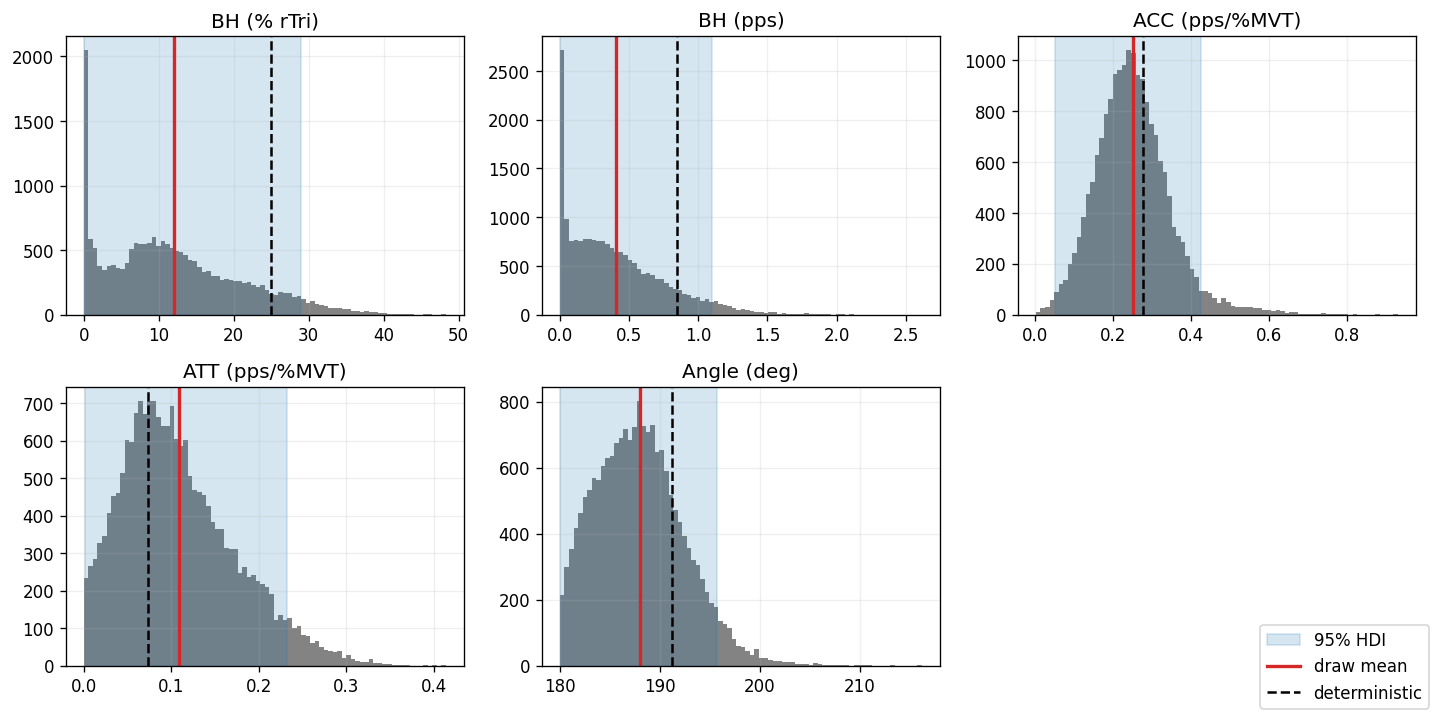

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.ravel()
for ax, (attr, label) in zip(axes, metric_names.items()):
    draws = hdi_result.ci.draws[attr]
    iv = hdi_result.ci.intervals[attr]
    ax.hist(draws, bins=80, color="0.35", alpha=0.75)
    ax.axvspan(iv.lower, iv.upper, color="tab:blue", alpha=0.18, label="95% HDI")
    ax.axvline(iv.mean, color="tab:red", linewidth=2, label="draw mean")
    ax.axvline(getattr(deterministic, attr), color="black", linestyle="--", linewidth=1.5, label="deterministic")
    ax.set_title(label)
    ax.grid(alpha=0.2)
axes[-1].axis("off")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower right")
fig.tight_layout()
plt.show()

## Sensitivity analysis

This section varies analysis choices that are passed directly to `compute_brace_pic(...)`:

- data inclusion at the start and end of the analysed segment via `recruitment_idx` and `peak_idx`
- endpoint/brace averaging via `recruitment_window`, `peak_window`, and `brace_window`
- `phase_fit` (`endpoints` or `ols`)
- `peak_torque_tolerance_s`

Keep the grid modest first. Large grids can be slow because each row calls `compute_brace_pic(...)`.

In [8]:
sensitivity_grid = {
    "recruitment_shift_samples": [0, 5, 20, 50],
    "peak_shift_samples": [0, -5, -20, -50],
    "recruitment_window": [1, 5, 11, 21],
    "peak_window": [1, 5, 11, 21],
    "brace_window": [1, 3, 5, 11],
    "phase_fit": ["endpoints", "ols"],
    "peak_torque_tolerance_s": [0.0, 0.05, 0.10, 0.25],
}

def sensitivity_rows(base_result, max_rows: int | None = None):
    keys = list(sensitivity_grid)
    combos = itertools.product(*(sensitivity_grid[k] for k in keys))
    for i, values in enumerate(combos):
        if max_rows is not None and i >= max_rows:
            break
        params = dict(zip(keys, values))

        rec_idx = int(base_result.recruitment_idx + params["recruitment_shift_samples"])
        peak_idx = int(base_result.peak_idx + params["peak_shift_samples"])
        rec_idx = max(0, min(rec_idx, len(trace["smooth_rate"]) - 3))
        peak_idx = max(rec_idx + 2, min(peak_idx, len(trace["smooth_rate"]) - 1))

        try:
            res = compute_brace_pic(
                trace["smooth_rate"],
                trace["reference"],
                fsamp=fsamp,
                time=trace["time"],
                recruitment_idx=rec_idx,
                peak_idx=peak_idx,
                peak_reference_idx=trace["peak_reference_idx"],
                reference_unit=BRACE_KWARGS["reference_unit"],
                discharge_unit=BRACE_KWARGS["discharge_unit"],
                distance_mode=BRACE_KWARGS["distance_mode"],
                phase_fit=params["phase_fit"],
                recruitment_window=params["recruitment_window"],
                peak_window=params["peak_window"],
                brace_window=params["brace_window"],
                peak_torque_tolerance_s=params["peak_torque_tolerance_s"],
            )
            yield {
                **params,
                "recruitment_idx": rec_idx,
                "peak_idx": peak_idx,
                "valid": res.valid,
                "exclusion_reasons": "; ".join(res.exclusion_reasons),
                "brace_height_norm": res.brace_height_norm,
                "acceleration_slope": res.acceleration_slope,
                "attenuation_slope": res.attenuation_slope,
                "angle": res.angle,
            }
        except Exception as exc:
            yield {**params, "recruitment_idx": rec_idx, "peak_idx": peak_idx, "valid": False, "error": str(exc)}

sensitivity = pd.DataFrame(sensitivity_rows(deterministic))
print(f"Sensitivity rows: {len(sensitivity)}")
display(sensitivity.head())

Sensitivity rows: 8192


,recruitment_shift_samples,peak_shift_samples,recruitment_window,peak_window,brace_window,phase_fit,peak_torque_tolerance_s,recruitment_idx,peak_idx,valid,exclusion_reasons,brace_height_norm,acceleration_slope,attenuation_slope,angle
0,0,0,1,1,1,endpoints,0.00,0,314,False,peak discharge after peak force/torque,24.926755,0.276051,0.073506,191.228197
1,0,0,1,1,1,endpoints,0.05,0,314,True,,24.926755,0.276051,0.073506,191.228197
2,0,0,1,1,1,endpoints,0.10,0,314,True,,24.926755,0.276051,0.073506,191.228197
3,0,0,1,1,1,endpoints,0.25,0,314,True,,24.926755,0.276051,0.073506,191.228197
4,0,0,1,1,1,ols,0.00,0,314,False,peak discharge after peak force/torque,24.926755,0.263701,0.025177,191.228197


### Summarize sensitivity by processing step

The tables and plots below answer two different questions:

- **Overall spread**: how much each metric changes over all tested processing choices.
- **Factor effect**: for each parameter, the range of group medians across that parameter's tested values. This is more interpretable than raw spread because it isolates one processing step at a time while averaging over the rest of the grid.

`relative_to_hdi_sd` compares the factor effect to the jitter-SVR draw SD. Values near or above 1 mean that processing-choice sensitivity is as large as, or larger than, the HDI draw variability.

In [9]:
metric_cols = ["brace_height_norm", "acceleration_slope", "attenuation_slope", "angle"]
factor_cols = [
    "recruitment_shift_samples", "peak_shift_samples",
    "recruitment_window", "peak_window", "brace_window",
    "phase_fit", "peak_torque_tolerance_s",
]
STEP_BY_FACTOR = {
    "recruitment_shift_samples": "endpoint placement",
    "peak_shift_samples": "endpoint placement",
    "recruitment_window": "endpoint/window averaging",
    "peak_window": "endpoint/window averaging",
    "brace_window": "endpoint/window averaging",
    "phase_fit": "phase fitting",
    "peak_torque_tolerance_s": "peak-force timing tolerance",
}

valid_sensitivity = sensitivity[sensitivity["valid"]].copy()
invalid_count = len(sensitivity) - len(valid_sensitivity)
print(f"Valid sensitivity rows: {len(valid_sensitivity)}/{len(sensitivity)}; invalid rows: {invalid_count}")

overall = valid_sensitivity[metric_cols].agg(["count", "mean", "std", "min", "median", "max"]).T
if hdi_result.ci is not None:
    overall["hdi_draw_sd"] = [hdi_result.ci.intervals[m].sd for m in metric_cols]
display(overall)

factor_summaries = []
factor_group_medians = {}
for factor in factor_cols:
    grouped = valid_sensitivity.groupby(factor, dropna=False)[metric_cols].median()
    factor_group_medians[factor] = grouped
    ranges = grouped.max() - grouped.min()
    for metric, value in ranges.items():
        hdi_sd = hdi_result.ci.intervals[metric].sd if hdi_result.ci is not None else np.nan
        overall_std = overall.loc[metric, "std"]
        factor_summaries.append({
            "processing_step": STEP_BY_FACTOR[factor],
            "factor": factor,
            "metric": metric,
            "range_of_group_medians": value,
            "relative_to_hdi_sd": value / hdi_sd if hdi_sd and np.isfinite(hdi_sd) else np.nan,
            "relative_to_overall_std": value / overall_std if overall_std and np.isfinite(overall_std) else np.nan,
        })

factor_summary = pd.DataFrame(factor_summaries).sort_values("range_of_group_medians", ascending=False)
display(factor_summary)

ranked_by_metric = (
    factor_summary.sort_values(["metric", "range_of_group_medians"], ascending=[True, False])
    .groupby("metric", as_index=False)
    .head(3)
    .reset_index(drop=True)
)
display(ranked_by_metric)

pivot = factor_summary.pivot_table(
    index=["processing_step", "factor"],
    columns="metric",
    values="relative_to_hdi_sd",
    aggfunc="first",
).fillna(0.0)
display(pivot)

Valid sensitivity rows: 6656/8192; invalid rows: 1536


,count,mean,std,min,median,max,hdi_draw_sd
brace_height_norm,6656.0,31.889115,5.333104,21.905300,31.946203,45.410902,9.068643
acceleration_slope,6656.0,0.294285,0.024864,0.263701,0.288580,0.352721,0.097682
attenuation_slope,6656.0,0.026210,0.033724,-0.029262,0.021100,0.080561,0.064839
angle,6656.0,193.995522,1.962675,190.427346,194.008996,199.020642,4.413797


,processing_step,factor,metric,range_of_group_medians,relative_to_hdi_sd,relative_to_overall_std
4,endpoint placement,peak_shift_samples,brace_height_norm,8.483753,0.935504,1.590772
0,endpoint placement,recruitment_shift_samples,brace_height_norm,7.503495,0.827411,1.406966
24,peak-force timing tolerance,peak_torque_tolerance_s,brace_height_norm,3.596270,0.396561,0.674330
7,endpoint placement,peak_shift_samples,angle,3.458620,0.783593,1.762197
3,endpoint placement,recruitment_shift_samples,angle,2.909461,0.659174,1.482396
27,peak-force timing tolerance,peak_torque_tolerance_s,angle,2.010162,0.455427,1.024195
8,endpoint/window averaging,recruitment_window,brace_height_norm,1.869520,0.206152,0.350550
16,endpoint/window averaging,brace_window,brace_height_norm,1.807121,0.199271,0.338850
12,endpoint/window averaging,peak_window,brace_height_norm,1.519142,0.167516,0.284851
11,endpoint/window averaging,recruitment_window,angle,1.036785,0.234896,0.528251


,processing_step,factor,metric,range_of_group_medians,relative_to_hdi_sd,relative_to_overall_std
0,endpoint placement,recruitment_shift_samples,acceleration_slope,0.055975,0.573032,2.251272
1,phase fitting,phase_fit,acceleration_slope,0.017891,0.183161,0.719585
2,endpoint/window averaging,recruitment_window,acceleration_slope,0.003798,0.038881,0.152750
3,endpoint placement,peak_shift_samples,angle,3.458620,0.783593,1.762197
4,endpoint placement,recruitment_shift_samples,angle,2.909461,0.659174,1.482396
5,peak-force timing tolerance,peak_torque_tolerance_s,angle,2.010162,0.455427,1.024195
6,endpoint placement,peak_shift_samples,attenuation_slope,0.057933,0.893496,1.717863
7,phase fitting,phase_fit,attenuation_slope,0.043316,0.668055,1.284424
8,peak-force timing tolerance,peak_torque_tolerance_s,attenuation_slope,0.034518,0.532360,1.023532
9,endpoint placement,peak_shift_samples,brace_height_norm,8.483753,0.935504,1.590772


metric                                                 acceleration_slope     angle  attenuation_slope  brace_height_norm
processing_step             factor                                                                                       
endpoint placement          peak_shift_samples                   0.000000  0.783593           0.893496           0.935504
                            recruitment_shift_samples            0.573032  0.659174           0.000000           0.827411
endpoint/window averaging   brace_window                         0.000000  0.182914           0.004792           0.199271
                            peak_window                          0.000000  0.127756           0.004792           0.167516
                            recruitment_window                   0.038881  0.234896           0.000000           0.206152
peak-force timing tolerance peak_torque_tolerance_s              0.000000  0.455427           0.532360           0.396561
phase fitting               phase_fit                            0.183161  0.000000           0.668055           0.000000

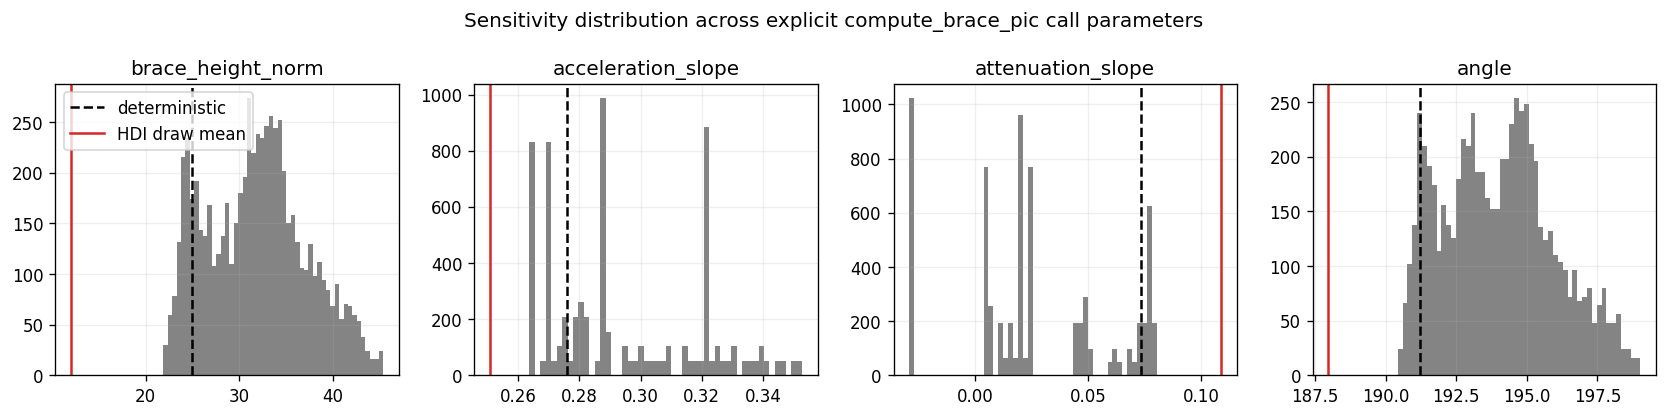

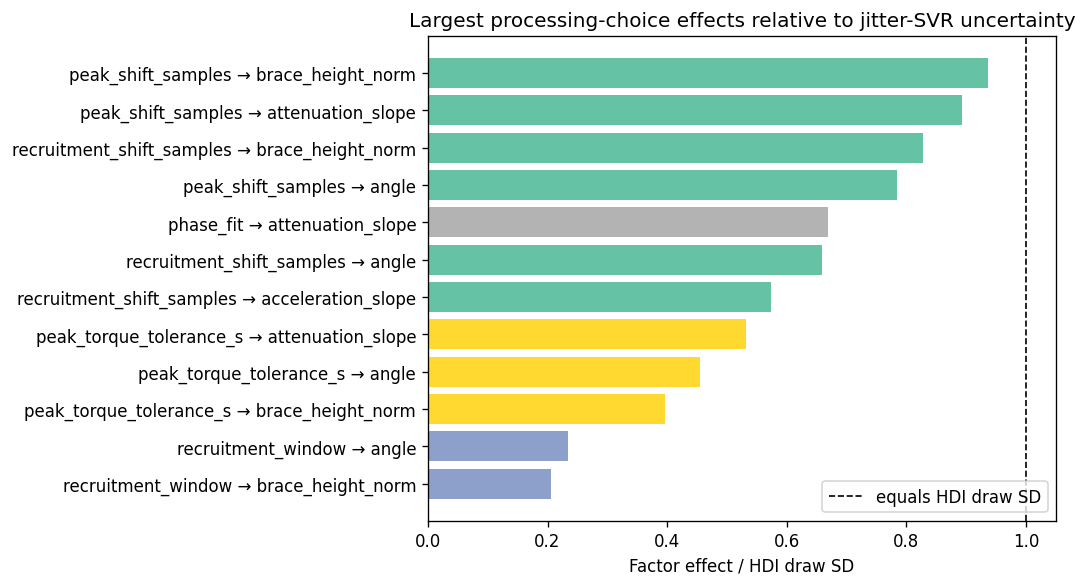

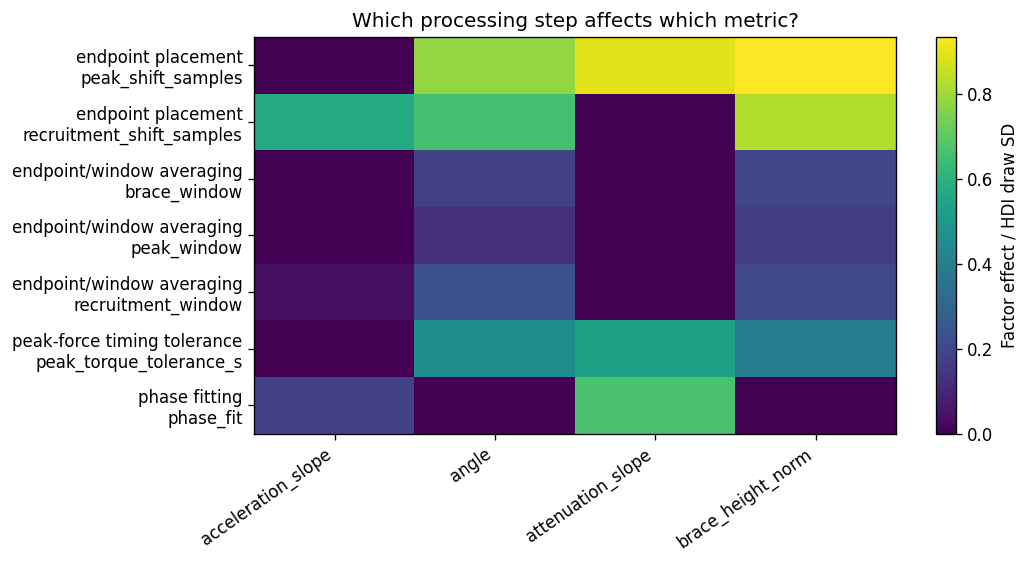

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, metric in zip(axes, metric_cols):
    ax.hist(valid_sensitivity[metric].dropna(), bins=50, color="0.4", alpha=0.8)
    ax.axvline(getattr(deterministic, metric), color="black", linestyle="--", label="deterministic")
    ax.axvline(getattr(hdi_result, metric), color="tab:red", label="HDI draw mean")
    ax.set_title(metric)
    ax.grid(alpha=0.2)
axes[0].legend()
fig.suptitle("Sensitivity distribution across explicit compute_brace_pic call parameters")
fig.tight_layout()
plt.show()

plot_summary = factor_summary.copy()
plot_summary["label"] = plot_summary["factor"] + " → " + plot_summary["metric"]
top_effects = plot_summary.sort_values("relative_to_hdi_sd", ascending=False).head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
colors = top_effects["processing_step"].astype("category").cat.codes
ax.barh(top_effects["label"], top_effects["relative_to_hdi_sd"], color=plt.cm.Set2(colors / max(colors.max(), 1)))
ax.axvline(1.0, color="black", linestyle="--", linewidth=1, label="equals HDI draw SD")
ax.set_xlabel("Factor effect / HDI draw SD")
ax.set_title("Largest processing-choice effects relative to jitter-SVR uncertainty")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

heat = pivot.copy()
fig, ax = plt.subplots(figsize=(9, 4.8))
im = ax.imshow(heat.to_numpy(), aspect="auto", cmap="viridis")
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=35, ha="right")
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels([f"{step}\n{factor}" for step, factor in heat.index])
fig.colorbar(im, ax=ax, label="Factor effect / HDI draw SD")
ax.set_title("Which processing step affects which metric?")
fig.tight_layout()
plt.show()

### Local SVR smoother sensitivity

This checks whether small deviations around the current SVR setting materially change the deterministic brace metrics. The grid is intentionally local around `SMOOTHER_KWARGS`, because these parameters should not diverge far from the paper/method setting unless the analysis is explicitly validating smoothing choices.

,C,gamma,epsilon,valid,exclusion_reasons,brace_height_norm,delta_brace_height_norm,acceleration_slope,delta_acceleration_slope,attenuation_slope,delta_attenuation_slope,angle,delta_angle
2,10.0,0.25,0.20,True,,20.184694,-4.742062,0.257679,-0.018371,0.091322,0.017816,189.231718,-1.996479
8,10.0,1.00,0.20,False,peak discharge after peak force/torque,20.443076,-4.483680,0.264600,-0.011451,0.066668,-0.006837,191.006632,-0.221565
17,20.0,1.00,0.20,False,peak discharge after peak force/torque,21.022510,-3.904245,0.266681,-0.009370,0.063584,-0.009921,191.293952,0.065755
14,20.0,0.50,0.20,False,peak discharge after peak force/torque,21.278190,-3.648566,0.284268,0.008218,0.095038,0.021533,190.439782,-0.788415
0,10.0,0.25,0.05,True,,21.938624,-2.988132,0.237809,-0.038242,0.074302,0.000796,189.127597,-2.100600
5,10.0,0.50,0.20,False,peak discharge after peak force/torque,22.085292,-2.841463,0.280350,0.004299,0.088525,0.015019,190.601911,-0.626287
9,20.0,0.25,0.05,False,peak discharge after peak force/torque,23.363136,-1.563620,0.241795,-0.034256,0.068035,-0.005471,189.700801,-1.527397
12,20.0,0.50,0.05,False,peak discharge after peak force/torque,23.523423,-1.403332,0.267295,-0.008756,0.076411,0.002906,190.595449,-0.632749
1,10.0,0.25,0.10,True,,23.625243,-1.301513,0.250888,-0.025162,0.069955,-0.003551,190.082544,-1.145653
23,40.0,0.50,0.20,False,peak discharge after peak force/torque,23.767138,-1.159618,0.304631,0.028581,0.084974,0.011468,192.085412,0.857215


,processing_step,factor,metric,range_of_group_medians,relative_to_hdi_sd
0,SVR smoothing,C,brace_height_norm,5.785193,0.637934
3,SVR smoothing,C,angle,1.619710,0.366965
8,SVR smoothing,epsilon,brace_height_norm,2.015632,0.222264
9,SVR smoothing,epsilon,acceleration_slope,0.021703,0.222178
11,SVR smoothing,epsilon,angle,0.954947,0.216355
10,SVR smoothing,epsilon,attenuation_slope,0.008872,0.136825
2,SVR smoothing,C,attenuation_slope,0.007971,0.122940
1,SVR smoothing,C,acceleration_slope,0.010456,0.107042
7,SVR smoothing,gamma,angle,0.000000,0.000000
6,SVR smoothing,gamma,attenuation_slope,0.000000,0.000000


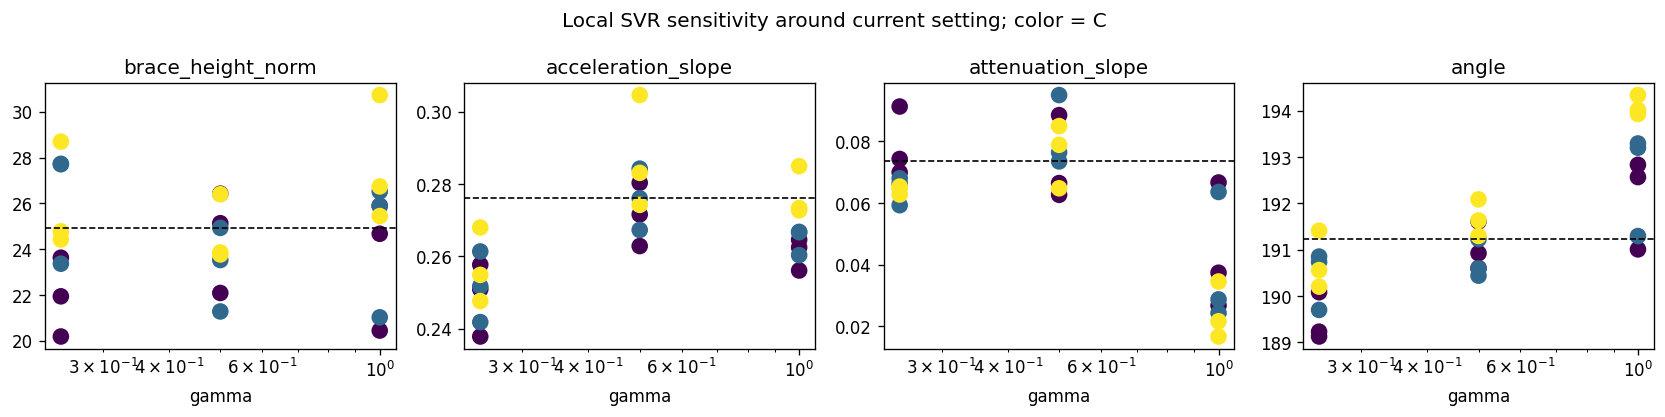

In [11]:
base_svr = {
    "C": float(SMOOTHER_KWARGS.get("C", 10.0)),
    "gamma": float(SMOOTHER_KWARGS.get("gamma", 0.5)),
    "epsilon": float(SMOOTHER_KWARGS.get("epsilon", 0.1)),
    "kernel": SMOOTHER_KWARGS.get("kernel", "rbf"),
}
svr_grid = {
    "C": sorted({max(base_svr["C"] / 2, 1e-9), base_svr["C"], base_svr["C"] * 2}),
    "gamma": sorted({max(base_svr["gamma"] / 2, 1e-9), base_svr["gamma"], base_svr["gamma"] * 2}),
    "epsilon": sorted({max(base_svr["epsilon"] / 2, 1e-9), base_svr["epsilon"], base_svr["epsilon"] * 2}),
}

svr_rows = []
for C, gamma, epsilon in itertools.product(svr_grid["C"], svr_grid["gamma"], svr_grid["epsilon"]):
    kwargs = {"C": C, "gamma": gamma, "epsilon": epsilon, "kernel": base_svr["kernel"]}
    _, smooth = smooth_discharge_rate_svr(trace["rate_times"], trace["idr"], trace["time"], **kwargs)
    res = compute_brace_pic(
        smooth,
        trace["reference"],
        fsamp=fsamp,
        time=trace["time"],
        peak_reference_idx=trace["peak_reference_idx"],
        **BRACE_KWARGS,
    )
    row = {"C": C, "gamma": gamma, "epsilon": epsilon, "valid": res.valid, "exclusion_reasons": "; ".join(res.exclusion_reasons)}
    for metric in metric_cols:
        row[metric] = getattr(res, metric)
        row[f"delta_{metric}"] = getattr(res, metric) - getattr(deterministic, metric)
    svr_rows.append(row)

svr_sensitivity = pd.DataFrame(svr_rows)
display(svr_sensitivity.sort_values("brace_height_norm"))

svr_effect_rows = []
for param in ["C", "gamma", "epsilon"]:
    grouped = svr_sensitivity[svr_sensitivity["valid"]].groupby(param)[metric_cols].median()
    ranges = grouped.max() - grouped.min()
    for metric, value in ranges.items():
        hdi_sd = hdi_result.ci.intervals[metric].sd if hdi_result.ci is not None else np.nan
        svr_effect_rows.append({
            "processing_step": "SVR smoothing",
            "factor": param,
            "metric": metric,
            "range_of_group_medians": value,
            "relative_to_hdi_sd": value / hdi_sd if hdi_sd and np.isfinite(hdi_sd) else np.nan,
        })
svr_effect_summary = pd.DataFrame(svr_effect_rows).sort_values("relative_to_hdi_sd", ascending=False)
display(svr_effect_summary)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, metric in zip(axes, metric_cols):
    ax.scatter(svr_sensitivity["gamma"], svr_sensitivity[metric], c=svr_sensitivity["C"], s=80, cmap="viridis")
    ax.axhline(getattr(deterministic, metric), color="black", linestyle="--", linewidth=1)
    ax.set_xscale("log")
    ax.set_xlabel("gamma")
    ax.set_title(metric)
fig.suptitle("Local SVR sensitivity around current setting; color = C")
fig.tight_layout()
plt.show()

## Suggested interpretation checklist

- The completed deterministic result in this sample notebook is invalid if `peak discharge after peak force/torque` is reported. Treat results as workflow diagnostics unless a valid triangular-ramp trial is used.
- Endpoint placement is expected to dominate brace-height and angle sensitivity when recruitment or peak indices are shifted.
- Endpoint/window averaging should mainly affect brace height and angle, with smaller effects on slopes unless the selected window crosses a local curvature change.
- Phase fitting should mainly affect acceleration/attenuation slopes; if it changes brace height, inspect whether the brace point or projection changes unexpectedly.
- Peak-force timing tolerance is a data-inclusion rule; if it changes results strongly, the MU peak discharge and peak force are temporally close or inverted.
- Local SVR sensitivity should remain modest around the paper/method setting. If small `C`, `gamma`, or `epsilon` changes move the metric as much as endpoint choices, report smoothing as a major uncertainty source.
- Keep `SMOOTHER_KWARGS`, `N_HDI_DRAWS`, validity flags, and the ranked sensitivity tables with any reported results.


## Sensitivity Interpretation

  - Brace height (BH) and angle are most sensitive to endpoint placement.
  - Peak shift drives BH and angle most strongly.
  - Recruitment shift drives acceleration slope.
  - Peak shift and phase fitting drive attenuation slope.
  - Peak-force timing tolerance has moderate effects on BH, angle, and attenuation slope.
  - Window averaging effects are smaller.
  - Local SVR sensitivity is not dominant, but C has moderate BH impact: about 0.64 x HDI draw SD.